# Exploratory Data Analysis (EDA) of Steam Store Games Dataset

**Course:** Statistics for Machine Learning and Data Science

**Name:** TOUHEED SHAIKH

**UIN:** 241A067

**Dataset:** Steam Store Games Dataset

**Source:** Kaggle

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
%matplotlib inline

In [2]:
df = pd.read_csv("steam.csv")
df.head()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  str    
 2   release_date      27075 non-null  str    
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  str    
 5   publisher         27061 non-null  str    
 6   platforms         27075 non-null  str    
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  str    
 9   genres            27075 non-null  str    
 10  steamspy_tags     27075 non-null  str    
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-null  int64  
 16  owners            27075 non-null  str    
 17  pric

# Part A: Dataset Understanding

## 1. Brief Description

The Steam Store Games dataset contains information about games available on the Steam digital distribution platform. It includes game details such as developer, publisher, release date, genres, pricing, ratings, playtime, achievements, supported platforms, and ownership estimates. This dataset can be used to analyze trends in game popularity, pricing strategies, and player engagement.

## Dataset Information

- **Dataset Source:** Kaggle
- **Number of Samples (Rows):** 27,075
- **Number of Features (Columns):** 18
- **Target Variable:** None (No prediction target is defined because this assignment focuses on Exploratory Data Analysis.)
- **Type of Problem:** Unsupervised / Exploratory Data Analysis

In [4]:
df.shape


(27075, 18)

In [5]:
df.columns.tolist()

['appid',
 'name',
 'release_date',
 'english',
 'developer',
 'publisher',
 'platforms',
 'required_age',
 'categories',
 'genres',
 'steamspy_tags',
 'achievements',
 'positive_ratings',
 'negative_ratings',
 'average_playtime',
 'median_playtime',
 'owners',
 'price']

# Part B: Data Inspection

In [6]:

df.head()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


In [7]:
df.tail()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
27070,1065230,Room of Pandora,2019-04-24,1,SHEN JIAWEI,SHEN JIAWEI,windows,0,Single-player;Steam Achievements,Adventure;Casual;Indie,Adventure;Indie;Casual,7,3,0,0,0,0-20000,2.09
27071,1065570,Cyber Gun,2019-04-23,1,Semyon Maximov,BekkerDev Studio,windows,0,Single-player,Action;Adventure;Indie,Action;Indie;Adventure,0,8,1,0,0,0-20000,1.69
27072,1065650,Super Star Blast,2019-04-24,1,EntwicklerX,EntwicklerX,windows,0,Single-player;Multi-player;Co-op;Shared/Split ...,Action;Casual;Indie,Action;Indie;Casual,24,0,1,0,0,0-20000,3.99
27073,1066700,New Yankee 7: Deer Hunters,2019-04-17,1,Yustas Game Studio,Alawar Entertainment,windows;mac,0,Single-player;Steam Cloud,Adventure;Casual;Indie,Indie;Casual;Adventure,0,2,0,0,0,0-20000,5.19
27074,1069460,Rune Lord,2019-04-24,1,Adept Studios GD,Alawar Entertainment,windows;mac,0,Single-player;Steam Cloud,Adventure;Casual;Indie,Indie;Casual;Adventure,0,4,0,0,0,0-20000,5.19


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  str    
 2   release_date      27075 non-null  str    
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  str    
 5   publisher         27061 non-null  str    
 6   platforms         27075 non-null  str    
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  str    
 9   genres            27075 non-null  str    
 10  steamspy_tags     27075 non-null  str    
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-null  int64  
 16  owners            27075 non-null  str    
 17  pric

In [9]:
df.dtypes

appid                 int64
name                    str
release_date            str
english               int64
developer               str
publisher               str
platforms               str
required_age          int64
categories              str
genres                  str
steamspy_tags           str
achievements          int64
positive_ratings      int64
negative_ratings      int64
average_playtime      int64
median_playtime       int64
owners                  str
price               float64
dtype: object

In [10]:
df.isnull().sum()

appid                0
name                 0
release_date         0
english              0
developer            1
publisher           14
platforms            0
required_age         0
categories           0
genres               0
steamspy_tags        0
achievements         0
positive_ratings     0
negative_ratings     0
average_playtime     0
median_playtime      0
owners               0
price                0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,appid,english,required_age,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,price
count,2.707500e+04,27075.000000,27075.000000,27075.000000,2.707500e+04,27075.000000,27075.000000,27075.00000,27075.000000
mean,5.962035e+05,0.981127,0.354903,45.248864,1.000559e+03,211.027147,149.804949,146.05603,6.078193
std,2.508942e+05,0.136081,2.406044,352.670281,1.898872e+04,4284.938531,1827.038141,2353.88008,7.874922
min,1.000000e+01,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000
25%,4.012300e+05,1.000000,0.000000,0.000000,6.000000e+00,2.000000,0.000000,0.00000,1.690000
50%,5.990700e+05,1.000000,0.000000,7.000000,2.400000e+01,9.000000,0.000000,0.00000,3.990000
75%,7.987600e+05,1.000000,0.000000,23.000000,1.260000e+02,42.000000,0.000000,0.00000,7.190000
max,1.069460e+06,1.000000,18.000000,9821.000000,2.644404e+06,487076.000000,190625.000000,190625.00000,421.990000


## Observations

- The dataset contains 27,075 records and 18 features.
- Most columns contain complete data with only a few missing values in the `developer` and `publisher` columns.
- The dataset consists of both numerical and categorical features.
- Numerical features such as price, achievements, ratings, and playtime show a wide range of values.
- The dataset appears suitable for Exploratory Data Analysis and Machine Learning after appropriate preprocessing.

# Part C: Data Visualization

## 1. Histogram of Game Prices

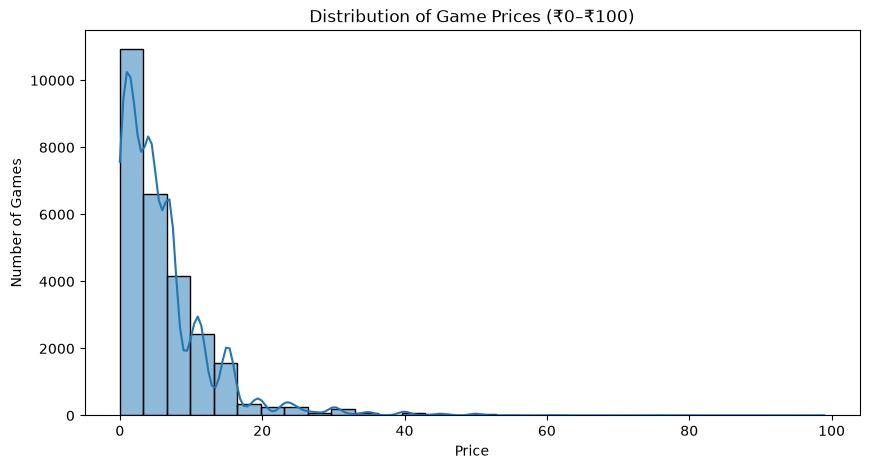

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(df[df["price"] <= 100]["price"], bins=30, kde=True)

plt.title("Distribution of Game Prices (₹0–₹100)")
plt.xlabel("Price")
plt.ylabel("Number of Games")

plt.show()

### Observations

1. Most Steam games are priced below $20, indicating that low-cost games are the most common.
2. The distribution is highly right skewed, with only a small number of games priced significantly higher.
3. A few expensive games act as outliers, extending the overall price range.

## 2. Box Plot of Game Prices

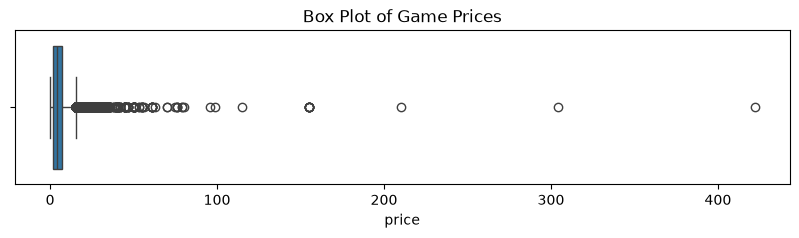

In [14]:
plt.figure(figsize=(10,2))

sns.boxplot(x=df["price"])

plt.title("Box Plot of Game Prices")

plt.show()

### Observations

1. Most Steam games are priced within a relatively low range, as indicated by the compact box near the lower prices.
2. There are many high-price outliers, with a few games priced above $300 and reaching approximately 422 Dollars.
3. The price distribution is positively (right) skewed, indicating that expensive games are much less common than low-priced games.

## 3. Scatter Plot: Price vs Positive Ratings

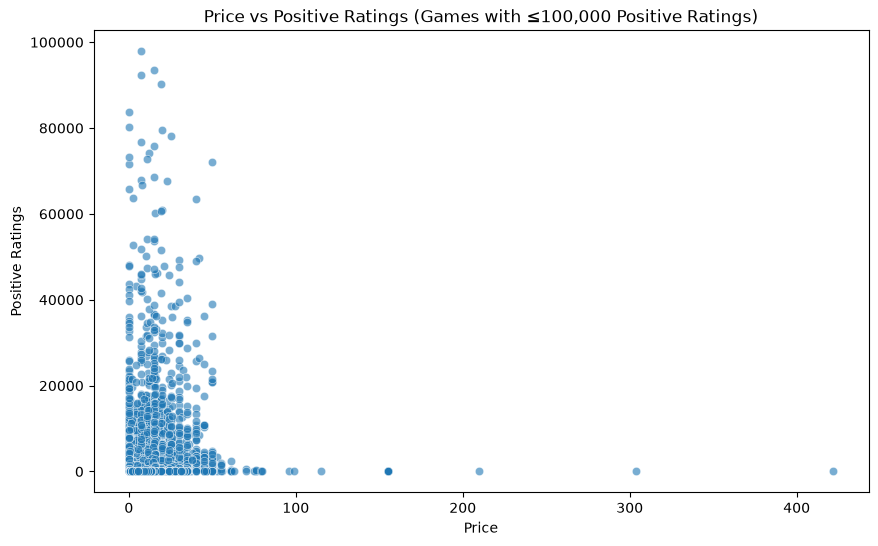

In [15]:
plt.figure(figsize=(10,6))

filtered_df = df[df["positive_ratings"] <= 100000]

sns.scatterplot(
    data=filtered_df,
    x="price",
    y="positive_ratings",
    alpha=0.6
)

plt.title("Price vs Positive Ratings (Games with ≤100,000 Positive Ratings)")
plt.xlabel("Price")
plt.ylabel("Positive Ratings")

plt.show()

### Observations

1. Most games have relatively low positive ratings regardless of their price.
2. No strong relationship is observed between a game's price and the number of positive ratings.
3. A few games receive exceptionally high positive ratings, indicating the presence of outliers.

## 4. Pair Plot of Selected Variables

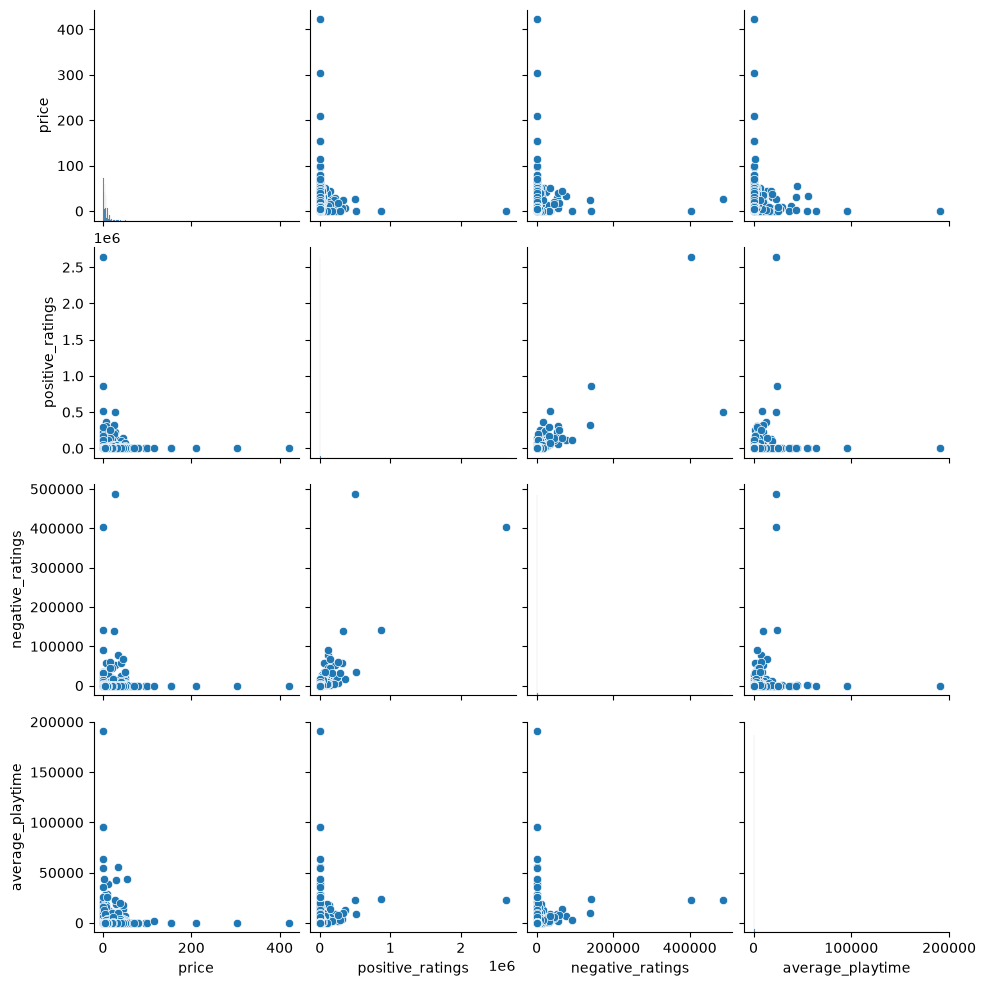

In [16]:
selected_features = [
    "price",
    "positive_ratings",
    "negative_ratings",
    "average_playtime"
]

sns.pairplot(df[selected_features])

plt.show()

### Observations

1. Positive ratings and negative ratings show a positive relationship, indicating that popular games receive more reviews of both types.
2. Price does not exhibit a strong relationship with playtime or ratings.
3. Several variables contain extreme outliers, causing most observations to cluster near the lower values.

## 5. Correlation Heatmap

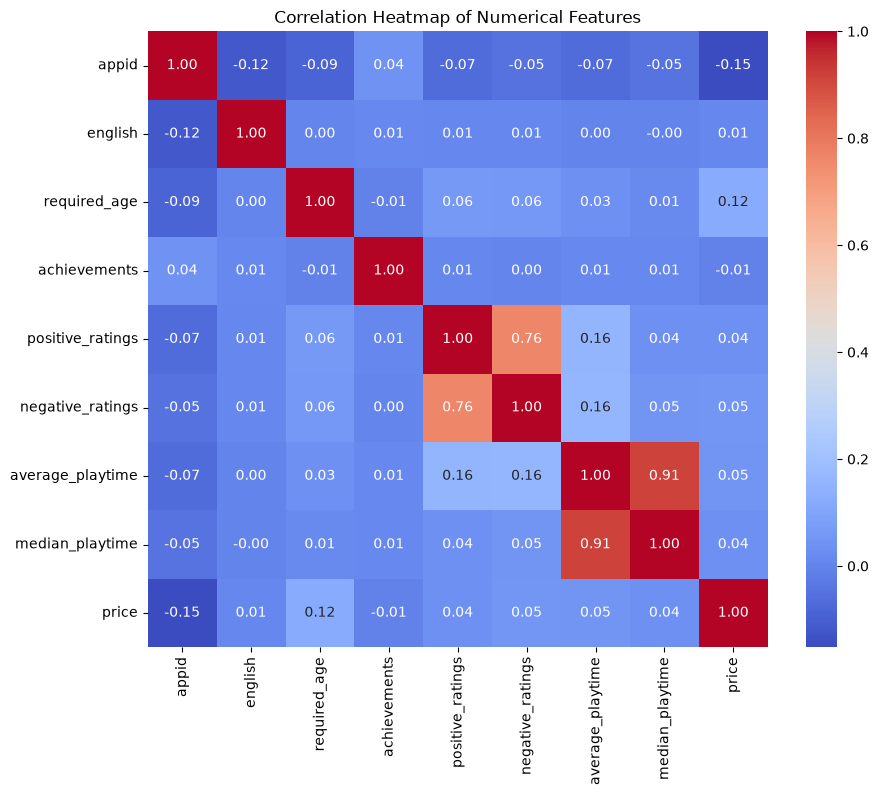

In [17]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=["int64", "float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

### Observations

1. Positive ratings and negative ratings have a strong positive correlation.
2. Price has a weak correlation with most numerical variables.
3. Average playtime and median playtime show a positive relationship, as expected.

# Part D: Descriptive Statistics

In [18]:
price = df["price"]

statistics = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median",
        "Mode",
        "Variance",
        "Standard Deviation",
        "Range",
        "Interquartile Range (IQR)",
        "Skewness",
        "Kurtosis"
    ],
    "Value": [
        price.mean(),
        price.median(),
        price.mode()[0],
        price.var(),
        price.std(),
        price.max() - price.min(),
        price.quantile(0.75) - price.quantile(0.25),
        price.skew(),
        price.kurt()
    ]
})

statistics["Value"] = statistics["Value"].round(2)

statistics

,Statistic,Value
0,Mean,6.08
1,Median,3.99
2,Mode,3.99
3,Variance,62.01
4,Standard Deviation,7.87
5,Range,421.99
6,Interquartile Range (IQR),5.50
7,Skewness,11.73
8,Kurtosis,420.82


## Interpretation

### Mean
The mean represents the average price of games available in the dataset.

### Median
The median represents the middle value of game prices. Since it is lower than the mean, it indicates that most games are inexpensive while a few expensive games increase the average price.

### Mode
The mode represents the most frequently occurring game price.

### Variance
Variance measures how widely the game prices are spread around the mean.

### Standard Deviation
A high standard deviation indicates significant variation in game prices.

### Range
The range represents the difference between the highest and lowest game price.

### Interquartile Range (IQR)
The IQR measures the spread of the middle 50% of game prices and is less affected by extreme values.

### Skewness
A positive skewness indicates that the distribution is right-skewed, meaning most games are low-priced with a few expensive games.

### Kurtosis
A high kurtosis value indicates the presence of extreme outliers in the dataset.

# Part E: Data Preprocessing

In [19]:
df.isnull().sum()

appid                0
name                 0
release_date         0
english              0
developer            1
publisher           14
platforms            0
required_age         0
categories           0
genres               0
steamspy_tags        0
achievements         0
positive_ratings     0
negative_ratings     0
average_playtime     0
median_playtime      0
owners               0
price                0
dtype: int64

In [20]:

df["developer"] = df["developer"].fillna("Unknown")
df["publisher"] = df["publisher"].fillna("Unknown")

df.isnull().sum()

appid               0
name                0
release_date        0
english             0
developer           0
publisher           0
platforms           0
required_age        0
categories          0
genres              0
steamspy_tags       0
achievements        0
positive_ratings    0
negative_ratings    0
average_playtime    0
median_playtime     0
owners              0
price               0
dtype: int64

### Justification

The `developer` and `publisher` columns contained a small number of missing values. These missing values were replaced with `"Unknown"` instead of deleting the records because only a few entries were affected, and removing rows would unnecessarily reduce the dataset size.

In [21]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["price"] < lower) | (df["price"] > upper)]

print("Number of Outliers:", len(outliers))

Number of Outliers: 1975


In [22]:
encoder = LabelEncoder()

df["developer_encoded"] = encoder.fit_transform(df["developer"])

df[["developer", "developer_encoded"]].head()

,developer,developer_encoded
0,Valve,15118
1,Valve,15118
2,Valve,15118
3,Valve,15118
4,Gearbox Software,5659


### Justification

The `developer` column was encoded into numerical values using Label Encoding. Machine Learning algorithms generally require numerical input, making encoding an essential preprocessing step.

In [23]:
scaler = StandardScaler()

df["price_scaled"] = scaler.fit_transform(df[["price"]])

df[["price", "price_scaled"]].head()

,price,price_scaled
0,7.19,0.141186
1,3.99,-0.265175
2,3.99,-0.265175
3,3.99,-0.265175
4,3.99,-0.265175


### Justification

The `price` feature was standardized using StandardScaler so that it has a mean close to 0 and a standard deviation close to 1. Standardization helps many Machine Learning algorithms perform better by ensuring features are on a similar scale.

# Part F: Sampling

In [24]:
random_sample = df.sample(frac=0.1, random_state=42)
random_sample.head()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price,developer_encoded,price_scaled
10506,514520,Sparky's Hunt,2016-08-18,1,Luke Cripps,Fellowplayer,windows,0,Single-player,Indie,Indie;Horror,14,6,3,0,0,0-20000,0.99,8406,-0.646138
26313,1012710,Endzeit,2019-04-03,1,RockyDev,RockyDev,windows,0,Single-player;Multi-player;Co-op;Full controll...,Action;Early Access,Early Access;Action;Violent,0,0,1,88,88,0-20000,7.19,11961,0.141186
2622,279260,Richard & Alice,2014-06-05,1,Owl Cave,Owl Cave,windows,0,Single-player;Steam Achievements;Steam Trading...,Adventure;Indie,Adventure;Indie;Point & Click,21,264,99,332,332,50000-100000,4.79,10390,-0.163585
1489,220090,The Journey Down: Chapter One,2013-01-09,1,SkyGoblin,SkyGoblin,windows;mac;linux,0,Single-player;Steam Trading Cards,Adventure;Indie,Adventure;Point & Click;Indie,0,902,129,303,327,200000-500000,5.99,12825,-0.011199
19949,788870,In The Long Run The Game,2018-07-02,1,Zerstoren Games,Zerstoren Games,windows,0,Single-player;Partial Controller Support,Action;Adventure;Indie;Simulation;Strategy;Ear...,Early Access;Simulation;Indie,0,6,11,0,0,0-20000,7.19,16127,0.141186


In [25]:
from sklearn.model_selection import train_test_split

stratified_sample, _ = train_test_split(
    df,
    test_size=0.9,
    stratify=df["required_age"],
    random_state=42
)

stratified_sample.head()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price,developer_encoded,price_scaled
12935,581300,Black Mirror,2017-11-28,1,KING Art,THQ Nordic,windows;mac;linux,0,Single-player;Steam Achievements;Full controll...,Violent;Adventure,Adventure;Violent;Horror,21,113,130,0,0,0-20000,24.99,7474,2.401567
26675,1031140,The Horus Heresy: Legions,2019-03-28,1,Everguild Ltd.,Everguild Ltd.,windows;mac,0,Single-player;Online Multi-Player;Cross-Platfo...,Free to Play;Strategy,Free to Play;Strategy;Card Game,24,155,65,0,0,50000-100000,0.00,4612,-0.771856
23918,912580,RAZ,2018-09-13,1,Team.WM,Team.WM,windows,0,Single-player;Multi-player;Online Multi-Player...,Action;Indie,Action;Indie,88,1,0,0,0,0-20000,0.79,14024,-0.671536
17812,726910,Star Wars: Droid Repair Bay,2017-12-06,1,ILMxLAB,"Disney Platform Distribution, Inc.",windows,0,Single-player;Steam Achievements,Adventure;Casual;Free to Play,Free to Play;Adventure;Casual,22,221,32,54,54,100000-200000,0.00,6614,-0.771856
12649,574070,Space Wars: Interstellar Empires,2017-12-08,1,Desert Owl Games LLC,ToHeroes Game Studios LLC,windows;mac,0,Online Multi-Player;MMO;Online Co-op;Cross-Pla...,Free to Play;Massively Multiplayer;Strategy;Ea...,Early Access;Free to Play;Massively Multiplayer,51,116,61,0,0,50000-100000,0.00,3709,-0.771856


In [26]:
comparison = pd.DataFrame({
    "Random Sample Mean Price": [random_sample["price"].mean()],
    "Stratified Sample Mean Price": [stratified_sample["price"].mean()],
    "Random Sample Std": [random_sample["price"].std()],
    "Stratified Sample Std": [stratified_sample["price"].std()]
})

comparison

,Random Sample Mean Price,Stratified Sample Mean Price,Random Sample Std,Stratified Sample Std
0,6.338759,6.032889,12.166778,7.489353


### Observations

1. Both sampling methods produce similar descriptive statistics.
2. Stratified sampling preserves the distribution of the `required_age` categories.
3. Both samples are representative of the original dataset and are suitable for further analysis.

# Part G: Conclusion

### Conclusion

The Steam Store Games dataset was successfully explored using Exploratory Data Analysis techniques.

The dataset contains 27,075 games with 18 features and only a few missing values. Various visualizations showed that most Steam games are low-priced, while a small number of games are significantly more expensive. Correlation analysis indicated a strong positive relationship between positive and negative ratings, as well as between average and median playtime.

The preprocessing stage included handling missing values, identifying outliers, encoding categorical variables, and standardizing numerical features. These steps prepared the dataset for future Machine Learning tasks.

Overall, the dataset is clean, informative, and highly suitable for further Machine Learning and Data Science applications such as recommendation systems, popularity prediction, and game market analysis.

# AI Ethical Usage Declaration

I declare that this assignment is my original work. Any Generative AI tools (such as ChatGPT, Gemini, GitHub Copilot, or similar) were used only to assist with learning, debugging, improving code readability, and understanding statistical concepts. I have independently verified all code, analysis, visualizations, interpretations, and conclusions presented in this notebook. Any external resources or AI assistance used have been appropriately acknowledged.